<a href="https://colab.research.google.com/github/ssb60386-beep/AI-LAB/blob/main/LAB_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
import os

print(os.listdir('/content'))

['.config', 'train.csv', 'sample_data']


In [4]:
import pandas as pd

df = pd.read_csv('/content/train.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("Number of records:", df.shape[0])
print("Number of features:", df.shape[1])

Number of records: 891
Number of features: 12


In [6]:
print("Feature names:")
print(df.columns.tolist())

Feature names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [7]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 0


In [10]:
display(df.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
print("Target variable: Survived")
print(df["Survived"].value_counts())

Target variable: Survived
Survived
0    549
1    342
Name: count, dtype: int64


In [12]:
display(df.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
display(df.describe(include='all'))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [14]:
duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


In [15]:
if duplicate_count > 0:
    df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (891, 12)


In [16]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

X = df[features]
y = df['Survived']

print("Input features:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Target variable:
Survived

X shape: (891, 7)
y shape: (891,)


In [17]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S
887,1,female,19.0,0,0,30.0000,S
888,3,female,NaN,1,2,23.4500,S
889,1,male,26.0,0,0,30.0000,C


In [18]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [19]:
print(y.value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [20]:
numerical_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare'
]

print("Numerical features:")
print(numerical_features)

Numerical features:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [21]:
categorical_features = [
    'Sex',
    'Embarked'
]

print("Categorical features:")
print(categorical_features)

Categorical features:
['Sex', 'Embarked']


In [22]:
print("Numerical feature data types:")
print(X[numerical_features].dtypes)

print("\nCategorical feature data types:")
print(X[categorical_features].dtypes)

Numerical feature data types:
Pclass      int64
Age       float64
SibSp       int64
Parch       int64
Fare      float64
dtype: object

Categorical feature data types:
Sex         object
Embarked    object
dtype: object


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [24]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (712, 7)
Testing features: (179, 7)
Training target: (712,)
Testing target: (179,)


In [25]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [26]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [27]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [28]:
numerical_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare'
]

print("Numerical features:")
print(numerical_features)

Numerical features:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [29]:
categorical_features = [
    'Sex',
    'Embarked'
]

print("Categorical features:")
print(categorical_features)

Categorical features:
['Sex', 'Embarked']


In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

In [31]:
preprocessing_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

In [32]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

X = df[features]
y = df['Survived']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 7)
y shape: (891,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [34]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 7)
X_test shape: (179, 7)
y_train shape: (712,)
y_test shape: (179,)


In [35]:
X_train_processed = preprocessing_pipeline.fit_transform(X_train)

In [36]:
X_test_processed = preprocessing_pipeline.transform(X_test)

In [37]:
print("Original Training Data Shape:", X_train.shape)
print("Original Testing Data Shape:", X_test.shape)

print("Processed Training Data Shape:", X_train_processed.shape)
print("Processed Testing Data Shape:", X_test_processed.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Original Training Data Shape: (712, 7)
Original Testing Data Shape: (179, 7)
Processed Training Data Shape: (712, 10)
Processed Testing Data Shape: (179, 10)
Training Target Shape: (712,)
Testing Target Shape: (179,)


In [38]:
feature_names = preprocessing_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

print("Processed Feature Names:")

for feature in feature_names:
    print(feature)

Processed Feature Names:
num__Pclass
num__Age
num__SibSp
num__Parch
num__Fare
cat__Sex_female
cat__Sex_male
cat__Embarked_C
cat__Embarked_Q
cat__Embarked_S


In [39]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

In [40]:
display(X_train_processed_df.head())


,num__Pclass,num__Age,num__SibSp,num__Parch,num__Fare,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S
0,0.829568,-0.081135,-0.465084,-0.466183,0.513812,0.0,1.0,0.0,0.0,1.0
1,-0.370945,-0.081135,-0.465084,-0.466183,-0.662563,0.0,1.0,0.0,0.0,1.0
2,-1.571457,-0.081135,-0.465084,-0.466183,3.955399,0.0,1.0,0.0,0.0,1.0
3,0.829568,-0.887827,-0.465084,0.727782,-0.467874,1.0,0.0,0.0,0.0,1.0
4,-0.370945,0.110934,0.478335,0.727782,-0.115977,1.0,0.0,0.0,0.0,1.0


In [41]:
print("Missing values in processed training data:",
      X_train_processed_df.isnull().sum().sum())

print("Missing values in processed testing data:",
      X_test_processed_df.isnull().sum().sum())

Missing values in processed training data: 0
Missing values in processed testing data: 0


In [42]:
display(X_train_processed_df.describe())

,num__Pclass,num__Age,num__SibSp,num__Parch,num__Fare,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S
count,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,712.000000,712.000000,712.000000,712.000000,712.000000
mean,-1.821265e-16,7.734138e-17,-5.613487e-18,-1.621674e-17,-1.746418e-17,0.355337,0.644663,0.195225,0.077247,0.727528
std,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,0.478952,0.478952,0.396652,0.267171,0.445544
min,-1.571457e+00,-2.238460e+00,-4.650843e-01,-4.661832e-01,-6.625632e-01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-3.709448e-01,-5.805160e-01,-4.650843e-01,-4.661832e-01,-4.981542e-01,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.295675e-01,-8.113533e-02,-4.650843e-01,-4.661832e-01,-3.615930e-01,0.000000,1.000000,0.000000,0.000000,1.000000
75%,8.295675e-01,4.950731e-01,4.783345e-01,-4.661832e-01,-1.707070e-02,1.000000,1.000000,0.000000,0.000000,1.000000
max,8.295675e-01,3.875496e+00,7.082266e+00,6.697610e+00,1.000533e+01,1.000000,1.000000,1.000000,1.000000,1.000000


In [43]:
print("========== FINAL RESULTS ==========")

print("Original Dataset:", df.shape)

print("Selected Features:", X.shape)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

print("Processed Training Data:", X_train_processed.shape)

print("Processed Testing Data:", X_test_processed.shape)

print("Training Target:", y_train.shape)

print("Testing Target:", y_test.shape)

========== FINAL RESULTS ==========
Original Dataset: (891, 12)
Selected Features: (891, 7)
Training Data: (712, 7)
Testing Data: (179, 7)
Processed Training Data: (712, 10)
Processed Testing Data: (179, 10)
Training Target: (712,)
Testing Target: (179,)


In [44]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [45]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [46]:
y_pred = model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8044692737430168

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8044692737430168

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



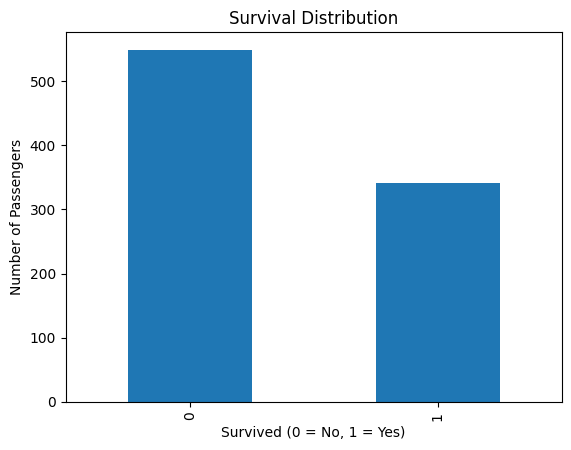

In [49]:
import matplotlib.pyplot as plt

df['Survived'].value_counts().plot(kind='bar')

plt.title('Survival Distribution')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

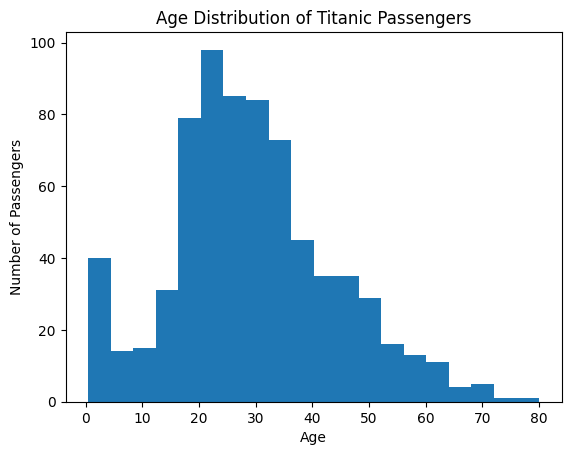

In [50]:
plt.hist(df['Age'].dropna(), bins=20)

plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

##**Question no :02**

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

In [54]:
from google.colab import files

uploaded = files.upload()

Saving winequality-red.csv to winequality-red.csv


In [55]:
df = pd.read_csv('/content/winequality-red.csv', sep=';')

In [56]:
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [57]:
print("Number of records:", df.shape[0])
print("Number of features:", df.shape[1])

Number of records: 1599
Number of features: 12


In [58]:
print("Feature names:")
print(df.columns.tolist())

Feature names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [59]:
print(df.dtypes)

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [60]:
print("Target variable: quality")

print("\nQuality values:")
print(df['quality'].value_counts().sort_index())

Target variable: quality

Quality values:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [61]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [62]:
print("Total missing values:",
      df.isnull().sum().sum())

Total missing values: 0


In [63]:
print("Number of duplicate records:",
      df.duplicated().sum())

Number of duplicate records: 240


In [64]:
df = df.drop_duplicates()

In [65]:
print("Dataset shape after removing duplicates:",
      df.shape)

Dataset shape after removing duplicates: (1359, 12)


In [66]:
print("Remaining duplicates:",
      df.duplicated().sum())

Remaining duplicates: 0


In [67]:
print("Total missing values after cleaning:",
      df.isnull().sum().sum())

Total missing values after cleaning: 0


In [68]:
display(df.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [69]:
X = df.drop('quality', axis=1)

In [70]:
y = df['quality']

In [71]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1359, 11)
y shape: (1359,)


In [72]:
print("Input features:")
display(X.head())

Input features:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4


In [73]:
print("Target:")
display(y.head())

Target:


,quality
0,5
1,5
2,5
3,6
5,5


In [74]:
print("Minimum values:")
print(X.min())

Minimum values:
fixed acidity           4.60000
volatile acidity        0.12000
citric acid             0.00000
residual sugar          0.90000
chlorides               0.01200
free sulfur dioxide     1.00000
total sulfur dioxide    6.00000
density                 0.99007
pH                      2.74000
sulphates               0.33000
alcohol                 8.40000
dtype: float64


In [75]:
print("\nMaximum values:")
print(X.max())


Maximum values:
fixed acidity            15.90000
volatile acidity          1.58000
citric acid               1.00000
residual sugar           15.50000
chlorides                 0.61100
free sulfur dioxide      72.00000
total sulfur dioxide    289.00000
density                   1.00369
pH                        4.01000
sulphates                 2.00000
alcohol                  14.90000
dtype: float64


In [76]:
feature_ranges = X.max() - X.min()

print("\nFeature ranges:")
print(feature_ranges)


Feature ranges:
fixed acidity            11.30000
volatile acidity          1.46000
citric acid               1.00000
residual sugar           14.60000
chlorides                 0.59900
free sulfur dioxide      71.00000
total sulfur dioxide    283.00000
density                   0.01362
pH                        1.27000
sulphates                 1.67000
alcohol                   6.50000
dtype: float64


In [77]:
print("Overall minimum:",
      np.min(X.values))

print("Overall maximum:",
      np.max(X.values))

Overall minimum: 0.0
Overall maximum: 289.0


In [78]:
print("\nMean of each feature:")
print(np.mean(X.values, axis=0))


Mean of each feature:
[ 8.31059603  0.52947756  0.2723326   2.52339956  0.08812362 15.8933039
 46.82597498  0.99670895  3.30978661  0.65870493 10.43231543]


In [79]:
print("\nStandard deviation of each feature:")
print(np.std(X.values, axis=0))


Standard deviation of each feature:
[1.73635062e+00 1.82963965e-01 1.95464590e-01 1.35181613e+00
 4.93586925e-02 1.04434258e+01 3.33966517e+01 1.86822940e-03
 1.54979260e-01 1.70604088e-01 1.08166727e+00]


In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [81]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (1087, 11)
Testing data shape: (272, 11)
Training target shape: (1087,)
Testing target shape: (272,)


In [82]:
standard_scaler = StandardScaler()

In [83]:
X_train_standard = standard_scaler.fit_transform(X_train)

In [84]:
X_test_standard = standard_scaler.transform(X_test)

In [85]:
minmax_scaler = MinMaxScaler()

In [86]:
X_train_minmax = minmax_scaler.fit_transform(X_train)

In [87]:
X_test_minmax = minmax_scaler.transform(X_test)

In [88]:
original_values = X_train.reset_index(drop=True)

In [89]:
standard_values = pd.DataFrame(
    X_train_standard,
    columns=X.columns
)

In [90]:
print("Original values:")
display(original_values.head())

Original values:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,8.9,0.38,0.40,2.2,0.068,12.0,28.0,0.99486,3.27,0.75,12.6
1,6.6,0.70,0.08,2.6,0.106,14.0,27.0,0.99665,3.44,0.58,10.2
2,6.8,0.56,0.03,1.7,0.084,18.0,35.0,0.99680,3.44,0.63,10.0
3,7.4,0.68,0.16,1.8,0.078,12.0,39.0,0.99770,3.50,0.70,9.9
4,7.8,0.59,0.18,2.3,0.076,17.0,54.0,0.99750,3.43,0.59,10.0


In [91]:
print("StandardScaler values:")
display(standard_values.head())

StandardScaler values:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.351623,-0.828323,0.648771,-0.238440,-0.411606,-0.362070,-0.566298,-0.986612,-0.259822,0.519851,1.984240
1,-0.981548,0.965891,-0.989833,0.054589,0.312800,-0.168479,-0.596342,-0.025508,0.857267,-0.458489,-0.215867
2,-0.865620,0.180922,-1.245865,-0.604727,-0.106593,0.218703,-0.355992,0.055032,0.857267,-0.170742,-0.399209
3,-0.517836,0.853753,-0.580182,-0.531470,-0.220973,-0.362070,-0.235817,0.538268,1.251534,0.232104,-0.490880
4,-0.285980,0.349130,-0.477769,-0.165183,-0.259100,0.121907,0.214839,0.430882,0.791556,-0.400940,-0.399209


In [92]:
minmax_values = pd.DataFrame(
    X_train_minmax,
    columns=X.columns
)

print("MinMaxScaler values:")
display(minmax_values.head())

MinMaxScaler values:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.380531,0.154930,0.40,0.089041,0.093489,0.154930,0.077739,0.351689,0.456897,0.251497,0.646154
1,0.176991,0.380282,0.08,0.116438,0.156928,0.183099,0.074205,0.483113,0.603448,0.149701,0.276923
2,0.194690,0.281690,0.03,0.054795,0.120200,0.239437,0.102473,0.494126,0.603448,0.179641,0.246154
3,0.247788,0.366197,0.16,0.061644,0.110184,0.154930,0.116608,0.560206,0.655172,0.221557,0.230769
4,0.283186,0.302817,0.18,0.095890,0.106845,0.225352,0.169611,0.545521,0.594828,0.155689,0.246154


In [93]:
print("Means after StandardScaler:")
print(X_train_standard.mean(axis=0))

Means after StandardScaler:
[ 3.57886061e-16 -1.14392805e-16 -4.57571219e-17 -2.61469268e-17
  8.33433292e-17 -1.47076463e-17  1.30734634e-17 -9.97505257e-15
 -3.01997005e-15 -4.11814097e-16 -8.87361328e-16]


In [94]:
print("\nStandard deviations after StandardScaler:")
print(X_train_standard.std(axis=0))


Standard deviations after StandardScaler:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [95]:
print("Minimum values after MinMaxScaler:")
print(X_train_minmax.min(axis=0))

print("\nMaximum values after MinMaxScaler:")
print(X_train_minmax.max(axis=0))

Minimum values after MinMaxScaler:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Maximum values after MinMaxScaler:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [96]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [97]:
X_train_processed = numerical_pipeline.fit_transform(X_train)

In [98]:
X_test_processed = numerical_pipeline.transform(X_test)

In [99]:
print("Processed training data:")
print(X_train_processed[:5])

Processed training data:
[[ 0.35162311 -0.82832312  0.64877105 -0.23844033 -0.41160622 -0.3620704
  -0.56629785 -0.98661183 -0.25982192  0.51985077  1.98424001]
 [-0.98154785  0.96589124 -0.98983279  0.05458922  0.31279969 -0.16847939
  -0.59634157 -0.02550786  0.85726724 -0.45848943 -0.2158671 ]
 [-0.86561994  0.18092246 -1.24586464 -0.60472726 -0.10659321  0.21870263
  -0.35599181  0.05503158  0.85726724 -0.17074231 -0.39920936]
 [-0.51783621  0.85375285 -0.58018183 -0.53146987 -0.22097309 -0.3620704
  -0.23581694  0.53826821  1.25153401  0.23210366 -0.49088049]
 [-0.2859804   0.34913006 -0.47776909 -0.16518294 -0.25909972  0.12190713
   0.21483885  0.43088229  0.79155612 -0.40094001 -0.39920936]]


In [100]:
print("Processed testing data:")
print(X_test_processed[:5])

Processed testing data:
[[-0.34394435  0.51733765 -1.19465827  0.93367786 -0.10659321  0.89627117
  -0.05555462  0.59196117  0.20015597 -0.74623655 -0.857565  ]
 [-0.05412458  0.60144145 -0.88742005 -0.31169771 -0.31628966  0.89627117
   0.39510116 -0.17047885 -0.12839966  0.51985077  0.42583081]
 [ 0.06180333 -0.88439232  0.80239016 -0.16518294 -0.50692279 -0.3620704
  -0.83669132 -0.64297689 -0.91693319  0.86514732  0.7008442 ]
 [ 0.93126266 -0.21156193  1.57048571  0.7139057   0.08403992 -0.65245691
  -0.11564206  1.98797812 -0.12839966 -0.45848943 -1.31592065]
 [-1.15543972  2.76010561 -1.39948375 -0.3849551  -0.12565652  0.12190713
  -0.68647273 -1.24970733  1.84293415 -0.6311377   0.7008442 ]]


In [101]:
print("========== DATASET SHAPES ==========")

print("Original dataset shape:",
      df.shape)

print("Training dataset shape:",
      X_train.shape)

print("Testing dataset shape:",
      X_test.shape)

print("Processed training data shape:",
      X_train_processed.shape)

print("Processed testing data shape:",
      X_test_processed.shape)

========== DATASET SHAPES ==========
Original dataset shape: (1359, 12)
Training dataset shape: (1087, 11)
Testing dataset shape: (272, 11)
Processed training data shape: (1087, 11)
Processed testing data shape: (272, 11)


In [102]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=X.columns
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=X.columns
)

In [103]:
display(X_train_processed_df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.351623,-0.828323,0.648771,-0.238440,-0.411606,-0.362070,-0.566298,-0.986612,-0.259822,0.519851,1.984240
1,-0.981548,0.965891,-0.989833,0.054589,0.312800,-0.168479,-0.596342,-0.025508,0.857267,-0.458489,-0.215867
2,-0.865620,0.180922,-1.245865,-0.604727,-0.106593,0.218703,-0.355992,0.055032,0.857267,-0.170742,-0.399209
3,-0.517836,0.853753,-0.580182,-0.531470,-0.220973,-0.362070,-0.235817,0.538268,1.251534,0.232104,-0.490880
4,-0.285980,0.349130,-0.477769,-0.165183,-0.259100,0.121907,0.214839,0.430882,0.791556,-0.400940,-0.399209


In [104]:
print("Missing values in processed training data:",
      X_train_processed_df.isnull().sum().sum())

print("Missing values in processed testing data:",
      X_test_processed_df.isnull().sum().sum())

Missing values in processed training data: 0
Missing values in processed testing data: 0


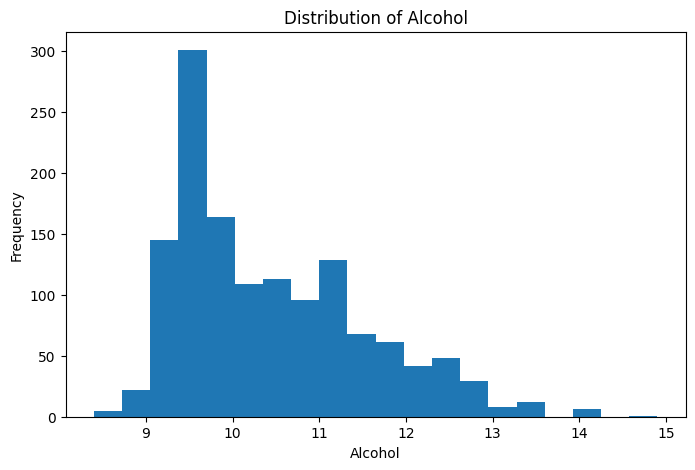

In [105]:
plt.figure(figsize=(8, 5))

plt.hist(df['alcohol'], bins=20)

plt.title('Distribution of Alcohol')
plt.xlabel('Alcohol')
plt.ylabel('Frequency')

plt.show()

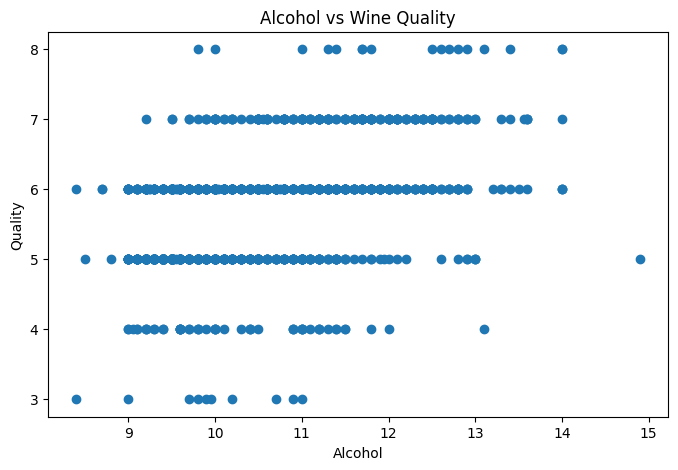

In [106]:
plt.figure(figsize=(8, 5))

plt.scatter(df['alcohol'], df['quality'])

plt.title('Alcohol vs Wine Quality')
plt.xlabel('Alcohol')
plt.ylabel('Quality')

plt.show()

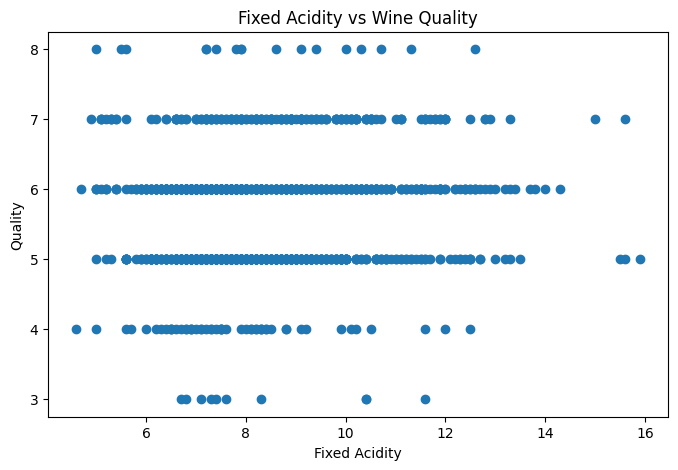

In [107]:
plt.figure(figsize=(8, 5))

plt.scatter(df['fixed acidity'], df['quality'])

plt.title('Fixed Acidity vs Wine Quality')
plt.xlabel('Fixed Acidity')
plt.ylabel('Quality')

plt.show()

In [108]:
alcohol_quality_corr = df['alcohol'].corr(df['quality'])

print("Correlation between alcohol and quality:",
      alcohol_quality_corr)

Correlation between alcohol and quality: 0.4803428980019918


In [109]:
acidity_quality_corr = df['fixed acidity'].corr(df['quality'])

print("Correlation between fixed acidity and quality:",
      acidity_quality_corr)

Correlation between fixed acidity and quality: 0.1190236656134977
